# Offline RL — training **fox** from a pre-collected dataset (critic-free PPO)

The **offline** sibling of [`../train_fox.ipynb`](../train_fox.ipynb). The live notebook
learns *while the sim runs* (collect a day of on-policy experience → pause at night → update).
Here we **split those halves in time**: collect a fixed dataset of transitions **once**, freeze
it to disk, then train the fox policy from that frozen data over as many passes as we like —
never touching the sim during training. That is the essence of *offline* RL: learning from
pre-collected data.

### Why not `imitation_learning/fox.npz`?
That behavioural-cloning file is a **reservoir sample** of independent `(obs → teacher action)`
rows (see `imitation.py`): **no rewards, no next-states, no `birth_id`, no tick**. Its rows
can't be grouped into per-agent trajectories, so a **cumulative discounted return can't be
accumulated along anything**, and there's no state to diff for a reward. Offline RL needs
transitions `(s, a, r, done)` in temporal order per agent — so this notebook **re-collects** a
trajectory-structured dataset, reusing the *identical* reward function the live trainer uses
(`ppo_live.compute_rewards`). Everything after that — **returns-to-go**, **whitening**, the
clipped PPO update — is the faithful offline analog of the live loop.

### Pipeline
1. **Collect** — run the sim with the fox driven by the warm-started clone (sampling
   stochastically); log every fox transition `(grids, scalars, action, old_logp, reward, done,
   controlled, episode, birth_id, tick)` → `fox_traj.npz`.
2. **Returns + normalize** — group rows into trajectories, compute discounted **returns-to-go**
   (death is terminal), **whiten** them into critic-free advantages.
3. **Offline PPO** — several clipped-surrogate rounds on the frozen batch, KL trust region.
4. **Export** — a drop-in TorchScript archive `sim.policy_brain` loads unchanged.

In [9]:
# --- bootstrap: reach offline_rl.py (this folder), ppo_live.py (parent), common.py (repo) ---
import sys, time
from pathlib import Path

_HERE = Path.cwd()
for _c in (_HERE, *_HERE.parents):
    if (_c / "notebooks" / "live_learning" / "offline" / "offline_rl.py").exists():
        _OFF = _c / "notebooks" / "live_learning" / "offline"
        break
    if (_c / "offline_rl.py").exists():
        _OFF = _c
        break
else:
    raise RuntimeError("run this notebook from inside the ecosystem repo")
if str(_OFF) not in sys.path:
    sys.path.insert(0, str(_OFF))

import numpy as np
import torch
import matplotlib.pyplot as plt

import offline_rl as O          # the OFFLINE PPO engine (imports ppo_live -> common -> repo root)
import common as C
from config import make_config, SHEEP, FOX, SPECIES_NAMES
from sim.policy_brain import policy_brain_from_path   # frozen TorchScript opponent

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())

torch 2.11.0+cu128 | cuda: True


In [10]:
# --- configuration ---------------------------------------------------------------------
TRAIN = FOX            # the species that LEARNS in this notebook
OTHER = SHEEP          # the fixed (non-learning) opponent species

RUN_SEED = 7           # seeds torch's action-sampling RNG (collection) + per-world sim dynamics
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"

# ---- how the NON-training species (sheep) is driven during COLLECTION: "rule" or "model" ----
OPPONENT      = "model"                        # "rule"  -> calibrated RuleBrain (self-contained)
                                              # "model" -> a frozen trained policy (path below)
OPPONENT_PATH = C.MODEL_PATHS[OTHER]          # used only when OPPONENT == "model"

# the BEHAVIOUR policy that generates the dataset = the imitation clone, made stochastic. The
# OFFLINE training policy is rebuilt from this SAME checkpoint, so round 0 starts on-policy
# (importance ratio ~ 1) and then improves. Set to None to collect from a random-init policy.
WARM_TRAIN = C.MODEL_PATHS[TRAIN]             # notebooks/imitation_learning/fox.pt

# ---- collection: how much trajectory data to gather (collected ONCE, then reused) ----
WORLD_SEEDS     = list(range(12))             # distinct maps sampled as episodes (stops at cap)
WARMUP          = 100                         # ticks to settle founders before recording
RECORD_TICKS    = 600                         # max ticks recorded per world
MAX_TRANSITIONS = 80_0000                      # global cap on rows (bounds memory / dataset size)
DATASET         = _OFF / f"{SPECIES_NAMES[TRAIN]}_traj.npz"
RECOLLECT       = False                        # False -> reuse DATASET on disk if it exists

# ---- offline training ----
GAMMA    = 0.99
N_ROUNDS = 30                                   # offline PPO rounds over the frozen batch
REFRESH  = True                                # re-centre the KL trust region each round (>0)

OUT_TRAIN = _OFF / f"{SPECIES_NAMES[TRAIN]}_offline_ppo.pt"   # deployable, drop-in checkpoint

ppocfg = O.PPOConfig(
    gamma=GAMMA, clip=0.2, epochs=16, minibatch=2048, lr=1e-4,
    entropy_coef=0.005, max_grad_norm=0.5, target_kl=0.03,
)
rcfg = O.RewardConfig()        # reward/pain weights -- identical to the live trainer; tweak freely

torch.manual_seed(RUN_SEED)    # reproducible action sampling during collection
assert OPPONENT in ("rule", "model")
print(f"offline-training {SPECIES_NAMES[TRAIN]} | {SPECIES_NAMES[OTHER]} (collection) = {OPPONENT}")
ppocfg, rcfg

offline-training fox | sheep (collection) = model


(PPOConfig(gamma=0.99, clip=0.2, epochs=16, minibatch=2048, lr=0.0001, entropy_coef=0.005, max_grad_norm=0.5, target_kl=0.03, max_agents=128, night_hi=0.5, night_lo=0.2, min_cycle=60, horizon=400),
 RewardConfig(survive_bonus=0.02, eat_gain_scale=4.0, drink_bonus=0.15, drink_thr=0.25, repro_bonus=2.0, health_gain_scale=1.0, need_penalty=0.02, death_penalty=2.0, age_death_frac=0.9))

## Step 1 — collect the trajectory dataset

Run the sim across `WORLD_SEEDS` (each world = one episode). The fox is driven by the
warm-started clone **sampling stochastically**; after every tick each fox that acted is rewarded
by `ppo_live.compute_rewards` (snapshot-and-diff on energy / health / reproduction / death — no
sim modification) and its transition is logged **in tick order**, tagged with
`(episode, birth_id, tick)` so trajectories can be reassembled. Collection stops at
`MAX_TRANSITIONS`. This is the only sim-touching step; set `RECOLLECT=False` to reuse the saved
`.npz` on later runs.

In [11]:
# --- collect (or reload) the offline transition dataset ----------------------------------
if DATASET.exists() and not RECOLLECT:
    print(f"loading existing dataset: {DATASET.name}")
    data = O.load_offline_dataset(DATASET)
    meta = None
    print("  rows:", data["grids"].shape[0], "| grids", data["grids"].shape[1:])
else:
    # behaviour policy: the clone made stochastic (its learnable heading log-std gives spread)
    behavior = O.build_ppo_policy(TRAIN, warm_start=WARM_TRAIN, device=DEVICE)

    if OPPONENT == "model":
        opponent = policy_brain_from_path(str(OPPONENT_PATH), OTHER, device=DEVICE)
        print("opponent:", OPPONENT_PATH)
    else:
        opponent = None                        # -> calibrated RuleBrain on the run RNG
        print("opponent: calibrated RuleBrain")

    t0 = time.time()
    data, meta = O.collect_offline_dataset(
        WORLD_SEEDS, behavior, opponent, rcfg,
        warmup=WARMUP, record_ticks=RECORD_TICKS, max_transitions=MAX_TRANSITIONS,
        train_species=TRAIN, other_species=OTHER, run_seed=RUN_SEED, device=DEVICE)
    O.save_offline_dataset(DATASET, data)
    mb = DATASET.stat().st_size / 1e6
    print(f"\nsaved {DATASET.name} ({mb:.1f} MB) in {time.time()-t0:.1f}s")

loading existing dataset: fox_traj.npz
  rows: 80016 | grids (5, 57, 57)


## Step 2 — returns-to-go + normalization

Group the flat rows into per-agent trajectories `(episode, birth_id)`, order by tick, and
compute the **discounted return-to-go** for every step with the same backward recurrence the
live buffer uses (a **death is terminal** — the sum doesn't bootstrap past it). Then **whiten**
the returns to a baseline over the *controlled* rows only → critic-free advantages
(mean 0, std 1). This is the "cumulative reward + normalization".

In [12]:
# --- build the training batch: discounted returns-to-go + whitened advantages ------------
batch = O.build_offline_batch(data, gamma=GAMMA)

R = batch["returns"]; A = batch["adv"]; ctrl = batch["controlled"]
print(f"trajectories : {batch['n_trajectories']}")
print(f"transitions  : {R.shape[0]}  ({ctrl.mean()*100:.1f}% controlled)")
print(f"return-to-go : min {R.min():+.3f} | mean {R.mean():+.3f} | max {R.max():+.3f}")
print(f"advantage    : mean {A.mean():+.3f} | std {A.std():.3f}  (whitened)")
if meta is not None:
    print(f"deaths seen  : {meta['n_deaths']}")

# reward gate rates in the collected data (a healthy fox should EAT and REPRO sometimes)
act = data["actions"]
print(f"action rates : eat={act[:,2].mean():.2f} drink={act[:,3].mean():.2f} "
      f"repro={act[:,4].mean():.2f} speed={act[:,5].mean():.2f}")

trajectories : 244
transitions  : 80016  (82.9% controlled)
return-to-go : min -2.019 | mean +1.216 | max +8.243
advantage    : mean -0.004 | std 1.003  (whitened)
action rates : eat=0.10 drink=0.18 repro=0.24 speed=0.70


## Step 3 — offline PPO

Rebuild the fox policy from the **same** warm-start (so round 0's importance ratio is ~1, i.e.
the first update starts exactly on-policy), then run several clipped-surrogate rounds on the
frozen batch. Advantages are fixed (critic-free — they come from the logged returns); with
`REFRESH=True` each round after the first re-centres `old_logp` on the current policy so the KL
early-stop measures that round's own movement and successive rounds keep improving.

In [13]:
# --- build the trainable policy (warm-started identically) + run offline PPO --------------
policy = O.build_ppo_policy(TRAIN, warm_start=WARM_TRAIN, device=DEVICE)
optimizer = torch.optim.Adam(policy.parameters(), lr=ppocfg.lr)

print(f"offline PPO: {N_ROUNDS} rounds x {ppocfg.epochs} epochs over {batch['returns'].shape[0]} transitions\n")
history = O.offline_ppo_train(policy, optimizer, batch, ppocfg,
                              n_rounds=N_ROUNDS, refresh=REFRESH, device=DEVICE)

offline PPO: 30 rounds x 16 epochs over 80016 transitions

  round  0/30 | meanR=+1.216 ploss=-0.0075 ent=2.001 kl=0.0046 clip=0.070
  round  1/30 | meanR=+1.216 ploss=-0.0087 ent=1.986 kl=0.0139 clip=0.073
  round  2/30 | meanR=+1.216 ploss=-0.0112 ent=1.972 kl=0.0238 clip=0.088
  round  3/30 | meanR=+1.216 ploss=-0.0035 ent=1.970 kl=0.0243 clip=0.077
  round  4/30 | meanR=+1.216 ploss=-0.0082 ent=1.970 kl=0.0281 clip=0.085
  round  5/30 | meanR=+1.216 ploss=-0.0097 ent=1.973 kl=0.0253 clip=0.056
  round  6/30 | meanR=+1.216 ploss=-0.0052 ent=1.979 kl=0.0244 clip=0.054
  round  7/30 | meanR=+1.216 ploss=-0.0127 ent=1.978 kl=0.0286 clip=0.047
  round  8/30 | meanR=+1.216 ploss=+0.0003 ent=1.987 kl=0.0282 clip=0.042
  round  9/30 | meanR=+1.216 ploss=-0.0038 ent=1.985 kl=0.0379 clip=0.057
  round 10/30 | meanR=+1.216 ploss=-0.0025 ent=1.983 kl=0.0237 clip=0.032
  round 11/30 | meanR=+1.216 ploss=+0.0135 ent=1.999 kl=0.0278 clip=0.038
  round 12/30 | meanR=+1.216 ploss=-0.0150 ent=1.993 

In [14]:
# --- export the deployable fox policy (drop-in TorchScript archive) -----------------------
O.export_policy(TRAIN, policy, OUT_TRAIN,
                meta={"offline": True, "rounds": N_ROUNDS, "gamma": GAMMA,
                      "transitions": int(batch["returns"].shape[0]),
                      "trajectories": int(batch["n_trajectories"])})
print("wrote", OUT_TRAIN)

_other_flag = (f"--{SPECIES_NAMES[OTHER]}-brain {OPPONENT_PATH} ") if OPPONENT == "model" else ""
print("\nDeploy with, e.g.:")
print(f"  venv/Scripts/python.exe run_experiment.py --ticks 3000 --world-seed 12345 "
      f"--seed {RUN_SEED} \\\n    --{SPECIES_NAMES[TRAIN]}-brain {OUT_TRAIN} {_other_flag}"
      f"--out runs/{SPECIES_NAMES[TRAIN]}_offline_eval.csv --plot")

wrote c:\Users\afree\Desktop\ecosystem\notebooks\live_learning\offline\fox_offline_ppo.pt

Deploy with, e.g.:
  venv/Scripts/python.exe run_experiment.py --ticks 3000 --world-seed 12345 --seed 7 \
    --fox-brain c:\Users\afree\Desktop\ecosystem\notebooks\live_learning\offline\fox_offline_ppo.pt --sheep-brain C:\Users\afree\Desktop\ecosystem\notebooks\imitation_learning\sheep.pt --out runs/fox_offline_eval.csv --plot


## Metrics

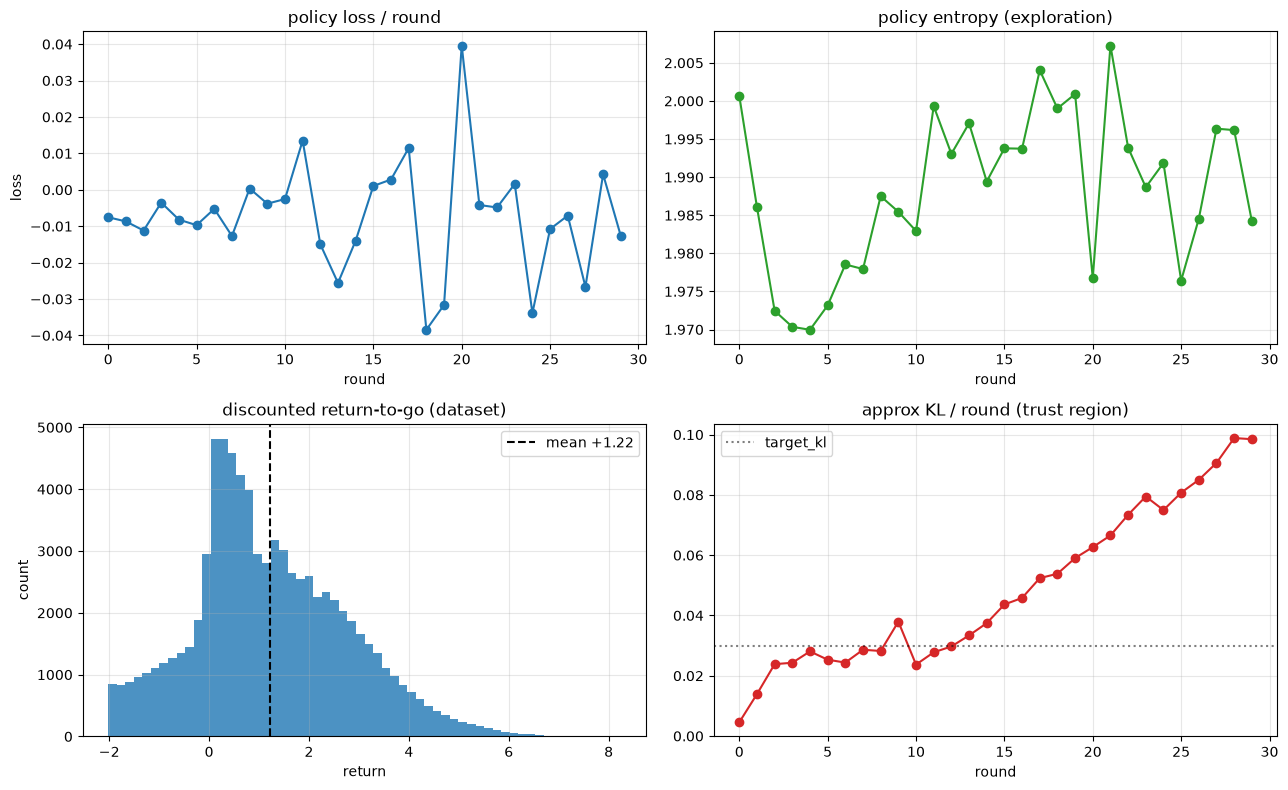

In [15]:
# --- learning curve + data diagnostics ----------------------------------------------------
if history:
    xs = [h["round"] for h in history]
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))

    ax[0, 0].plot(xs, [h["policy_loss"] for h in history], "-o")
    ax[0, 0].set(title="policy loss / round", xlabel="round", ylabel="loss"); ax[0, 0].grid(alpha=.3)

    ax[0, 1].plot(xs, [h["entropy"] for h in history], "-o", color="tab:green")
    ax[0, 1].set(title="policy entropy (exploration)", xlabel="round"); ax[0, 1].grid(alpha=.3)

    ax[1, 1].plot(xs, [h["approx_kl"] for h in history], "-o", color="tab:red")
    ax[1, 1].axhline(ppocfg.target_kl, color="k", ls=":", alpha=.5, label="target_kl")
    ax[1, 1].set(title="approx KL / round (trust region)", xlabel="round"); ax[1, 1].legend(); ax[1, 1].grid(alpha=.3)

    # distribution of discounted returns-to-go in the dataset
    ax[1, 0].hist(batch["returns"], bins=60, color="tab:blue", alpha=.8)
    ax[1, 0].axvline(float(batch["returns"].mean()), color="k", ls="--",
                     label=f"mean {batch['returns'].mean():+.2f}")
    ax[1, 0].set(title="discounted return-to-go (dataset)", xlabel="return", ylabel="count")
    ax[1, 0].legend(); ax[1, 0].grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("no rounds run yet -- execute Step 3 above")

In [16]:
# --- population dynamics during COLLECTION (per episode; only if freshly collected) -------
if meta is not None and meta.get("pop_log"):
    pl = np.array(meta["pop_log"])          # (episode, tick, n_sheep, n_fox)
    step = np.arange(len(pl))
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(step, pl[:, 2], label="sheep")
    ax.plot(step, pl[:, 3], label="fox")
    epoch_starts = np.flatnonzero(np.diff(pl[:, 0]) != 0) + 1
    for s in epoch_starts:
        ax.axvline(s, color="k", ls=":", alpha=.25)
    ax.set(title="population during collection (dotted = new world/episode)",
           xlabel="collection step (cumulative across worlds)", ylabel="count")
    ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
else:
    print("population log only available right after a fresh collection (RECOLLECT=True)")

population log only available right after a fresh collection (RECOLLECT=True)
